# DiaBites Chatbot - Training & Evaluation

Notebook ini mendemonstrasikan proses training model klasifikasi intent untuk DiaBites Chatbot.

## 1. Import Library & Setup Path

In [1]:
import os
import pickle
import numpy as np
import tensorflow as tf
import tf_keras
tf.keras = tf_keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Import callback kustom
import sys
sys.path.append("..")
from model.custom_callbacks import ConfidenceLogger

# Paths
NPZ_PATH = "../data/processed/processed_data.npz"
EMBEDDINGS_PATH = "../data/processed/pattern_embeddings.npy"
ENCODER_PATH = "../data/processed/label_encoder.pkl"
SAVED_MODEL_DIR = "../model/saved_model"
MODEL_WEIGHTS_PATH = os.path.join(SAVED_MODEL_DIR, "indobert_chatbot_weights.h5")

print("Setup selesai.")


Setup selesai.


## 2. Load Preprocessing

In [2]:
# Load pre-computed embeddings
embeddings = np.load(EMBEDDINGS_PATH)

# Load labels
data = np.load(NPZ_PATH)
labels = data['labels']

# Load label encoder
with open(ENCODER_PATH, "rb") as f:
    le = pickle.load(f)
num_classes = len(le.classes_)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Jumlah kelas intent: {num_classes}")
print(f"\nContoh kelas: {list(le.classes_[:5])}...")

Embeddings shape: (1310, 768)
Labels shape: (1310,)
Jumlah kelas intent: 41

Contoh kelas: ['app_feature_query', 'bmi_weight_query', 'bmr_tdee_query', 'calorie_query', 'carbohydrate_query']...


## 3. Membagi Data Train & Validation

Membagi data secara terlapis (stratified) dengan perbandingan 80% train dan 20% validation.

In [3]:
train_embs, val_embs, train_labels, val_labels = train_test_split(
    embeddings, labels, 
    test_size=0.2, 
    random_state=42, 
    stratify=labels
)

print(f"Split data selesai:")
print(f"  Train   : {len(train_labels)} sampel")
print(f"  Validasi: {len(val_labels)} sampel")

Split data selesai:
  Train   : 1048 sampel
  Validasi: 262 sampel


## 4. Arsitektur Model Classification Head

Model klasifikasi Dense head yang menerima input embedding 768-dimensi dari IndoBERT.

**Arsitektur:**
- Input: 768-dim CLS embedding
- Dense(512, ReLU) + Dropout(0.1)
- Dense(256, ReLU) + Dropout(0.1) 
- Dense(41, Softmax) → output prediksi kelas

In [4]:
def build_head_model(num_classes=41):
    """Membangun model klasifikasi Dense head mandiri di atas CLS embeddings."""
    input_emb = tf.keras.layers.Input(shape=(768,), name="input_embeddings")
    dropout1 = tf.keras.layers.Dropout(0.1)(input_emb)
    dense1 = tf.keras.layers.Dense(512, activation='relu', name="dense_classification_1")(dropout1)
    dropout2 = tf.keras.layers.Dropout(0.1)(dense1)
    dense2 = tf.keras.layers.Dense(256, activation='relu', name="dense_classification_2")(dropout2)
    dropout3 = tf.keras.layers.Dropout(0.1)(dense2)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='outputs')(dropout3)

    model = tf.keras.Model(inputs=input_emb, outputs=outputs)
    return model

tf.keras.backend.clear_session()

head_model = build_head_model(num_classes=num_classes)
head_model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_embeddings (InputLay  [(None, 768)]             0         
 er)                                                             
                                                                 
 dropout (Dropout)           (None, 768)               0         
                                                                 
 dense_classification_1 (De  (None, 512)               393728    
 nse)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_classification_2 (De  (None, 256)               131328    
 nse)                                                            
                                                            

## 5. Melatih Model (Training)

Melatih classification head di atas **seluruh** pre-computed embeddings.

In [5]:
# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
head_model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
conf_logger = ConfidenceLogger(val_data=(val_embs, val_labels))
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir="../logs/tensorboard", 
    histogram_freq=0  # PENTING: 0 untuk mencegah OOM
)

callbacks = [conf_logger, tensorboard_callback]

print("Melatih classification head di atas seluruh embeddings...\n")
history = head_model.fit(
    x=embeddings,
    y=labels,
    validation_data=(val_embs, val_labels),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining selesai!")

Melatih classification head di atas seluruh embeddings...

Epoch 1/150


41/41 [==============================] - ETA: 0s - loss: 3.5899 - accuracy: 0.0695
 - epoch 1 - val_avg_confidence: 0.0904
41/41 [==============================] - 3s 26ms/step - loss: 3.5899 - accuracy: 0.0695 - val_loss: 3.2116 - val_accuracy: 0.1527 - val_avg_confidence: 0.0904
Epoch 2/150
39/41 [===========================>..] - ETA: 0s - loss: 3.1026 - accuracy: 0.1474
 - epoch 2 - val_avg_confidence: 0.1716
41/41 [==============================] - 1s 17ms/step - loss: 3.1000 - accuracy: 0.1450 - val_loss: 2.8192 - val_accuracy: 0.2023 - val_avg_confidence: 0.1716
Epoch 3/150
38/41 [==========================>...] - ETA: 0s - loss: 2.8125 - accuracy: 0.2179
 - epoch 3 - val_avg_confidence: 0.2009
41/41 [==============================] - 1s 16ms/step - loss: 2.8120 - accuracy: 0.2176 - val_loss: 2.4392 - val_accuracy: 0.2748 - val_avg_confidence: 0.2009
Epoch 4/150
41/41 [==============================] - ETA:

## 6. Simpan Model Weights

In [6]:
os.makedirs(SAVED_MODEL_DIR, exist_ok=True)

# Simpan weights head model (bisa di-load oleh evaluate.py dan predict.py)
head_model.save_weights(MODEL_WEIGHTS_PATH)
print(f"Weights tersimpan di: {MODEL_WEIGHTS_PATH}")

Weights tersimpan di: ../model/saved_model\indobert_chatbot_weights.h5


## 7. Visualisasi Hasil Training

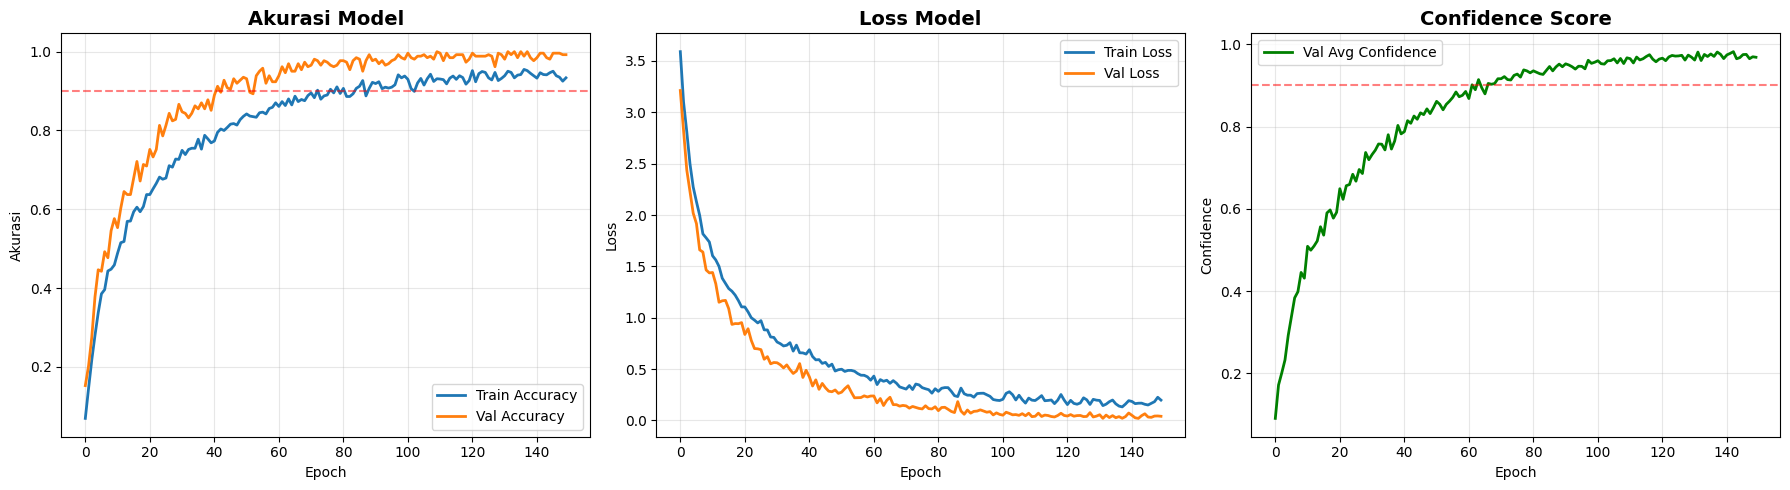

Grafik tersimpan di: ../logs/training_curves.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Akurasi Model', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='Target 90%')

# Plot Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Loss Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot Confidence
if 'val_avg_confidence' in history.history:
    axes[2].plot(history.history['val_avg_confidence'], label='Val Avg Confidence', 
                 linewidth=2, color='green')
    axes[2].set_title('Confidence Score', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Confidence')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=0.9, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../logs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan di: ../logs/training_curves.png")

## 8. Evaluasi Akhir & Classification Report

Mengevaluasi model pada validation set menggunakan pre-computed embeddings.

In [8]:
# Prediksi pada validation set
preds = head_model.predict(val_embs, batch_size=32, verbose=0)
pred_labels = np.argmax(preds, axis=1)

# Akurasi
acc = accuracy_score(val_labels, pred_labels)
print("=" * 50)
print(f"  AKURASI VALIDASI: {acc * 100:.2f}%")
print("=" * 50)

# Target check
if acc >= 0.90:
    print(f"\nTarget akurasi >= 90% berhasil dicapai! ({acc*100:.2f}%)")
else:
    print(f"\nTarget belum tercapai. Akurasi: {acc*100:.2f}%")

# Evaluasi seluruh dataset
all_preds = head_model.predict(embeddings, batch_size=32, verbose=0)
all_pred_labels = np.argmax(all_preds, axis=1)
all_acc = accuracy_score(labels, all_pred_labels)
print(f"Akurasi seluruh dataset: {all_acc * 100:.2f}%")

# Classification Report
print("\nClassification Report (Validation Set):")
print(classification_report(val_labels, pred_labels, target_names=le.classes_, digits=4))

  AKURASI VALIDASI: 99.24%

Target akurasi >= 90% berhasil dicapai! (99.24%)
Akurasi seluruh dataset: 99.39%

Classification Report (Validation Set):
                            precision    recall  f1-score   support

         app_feature_query     1.0000    1.0000    1.0000         6
          bmi_weight_query     0.8000    1.0000    0.8889         4
            bmr_tdee_query     1.0000    1.0000    1.0000         6
             calorie_query     1.0000    1.0000    1.0000         7
        carbohydrate_query     1.0000    1.0000    1.0000         7
         community_feature     1.0000    1.0000    1.0000         7
   community_ruang_berbagi     1.0000    1.0000    1.0000         6
    daily_wellness_feature     1.0000    1.0000    1.0000         6
          diabetes_general     1.0000    1.0000    1.0000         6
        diabetes_lifestyle     0.8750    1.0000    0.9333         7
            diabites_brand     1.0000    1.0000    1.0000         7
                disclaimer     1.